***Simple implementation of the convolution concept by applying a filter (kernel) to a matrix***

In [1]:
import numpy as np

image = np.array([
    [1,2,3,4,5],
    [6,7,8,9,10],
    [11,12,13,14,15],
    [16,17,18,19,20],
    [21,22,23,24,25]
])

filter = np.array([
    [1,0,1],
    [0,1,0],
    [1,0,1]
])
# Manually slide filter and compute output

# 2D Convolution manually
h_img, w_img = image.shape
h_f, w_f = filter.shape
out_h, out_w = h_img - h_f + 1, w_img - w_f + 1
output = np.zeros((out_h, out_w))

for i in range(out_h):
    for j in range(out_w):
        region = image[i:i+h_f, j:j+w_f]
        output[i, j] = np.sum(region * filter)

print("Manual 2DConvolution Result:")
print(output)

Manual 2DConvolution Result:
[[35. 40. 45.]
 [60. 65. 70.]
 [85. 90. 95.]]


***CNN Implementation using TensorFlow / Keras***

In [2]:
import numpy as np
from tensorflow.keras import layers, models

# 1. Define the CNN architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

# 2. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Display model architecture and trainable parameters
model.summary()

# 3. Quick verification run with synthetic data
X_dummy = np.random.random((100, 28, 28, 1)).astype(np.float32)
y_dummy = np.random.randint(0, 10, size=(100,))

# Train for 1 epoch to ensure everything works end-to-end
history = model.fit(X_dummy, y_dummy, epochs=1, batch_size=32)

C:\Users\HP\Desktop\sentientAI\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

1/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.0312 - loss: 2.3532

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.1000 - loss: 2.4269


***Model Predictions Output and Conv2D Feature Map Visualization***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step



--- Model Output and Predictions ---
Raw Output Probabilities for Sample 0:
 [0.15868111 0.07041167 0.06421211 0.03785874 0.06512978 0.10777527
 0.08232525 0.05735077 0.10526658 0.25098872]
Predicted Classes for First 5 Samples: [9 9 9 9 9]
Actual Classes for First 5 Samples:    [4 8 9 2 6]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


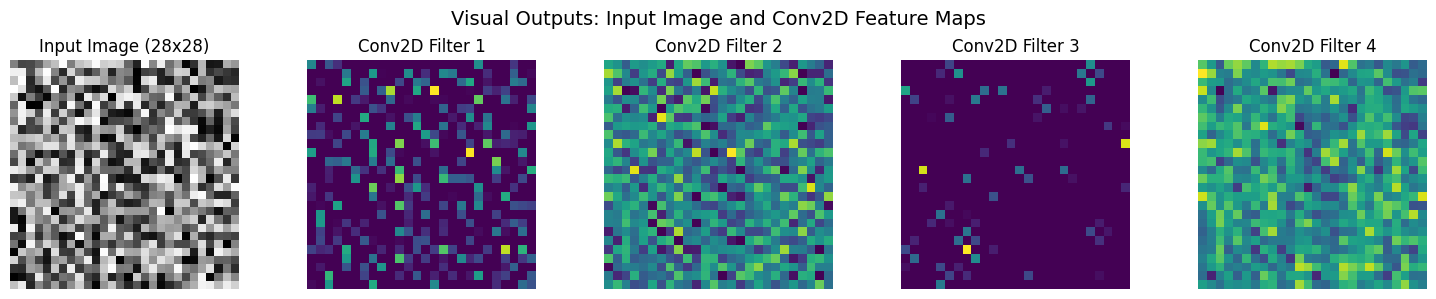

In [3]:
import matplotlib.pyplot as plt

# 4. Print Model Predictions Output
predictions = model.predict(X_dummy[:5])
predicted_classes = np.argmax(predictions, axis=1)
print("\n--- Model Output and Predictions ---")
print("Raw Output Probabilities for Sample 0:\n", predictions[0])
print("Predicted Classes for First 5 Samples:", predicted_classes)
print("Actual Classes for First 5 Samples:   ", y_dummy[:5])

# 5. Extract and Visualize Conv2D Feature Maps
feature_extractor = models.Model(inputs=model.inputs, outputs=model.layers[0].output)
feature_maps = feature_extractor.predict(X_dummy[:1])

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Plot original input image
axes[0].imshow(X_dummy[0].squeeze(), cmap='gray')
axes[0].set_title("Input Image (28x28)")
axes[0].axis('off')

# Plot first 4 feature maps extracted by Conv2D filters
for i in range(4):
    axes[i+1].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[i+1].set_title(f"Conv2D Filter {i+1}")
    axes[i+1].axis('off')

plt.suptitle("Visual Outputs: Input Image and Conv2D Feature Maps", fontsize=14)
plt.tight_layout()
plt.show()
